In [1]:
import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Omkar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,questions,model_answer,student_answer,teacher_marks,total_marks
0,What is respiration in plants?,Respiration in plants is the process of breaki...,Respiration is how plants and animals take in ...,3,5
1,Define evaporation.,Evaporation is the process where liquid turns ...,Evaporation is when water turns into gas and g...,3,5
2,Explain condensation.,Condensation is the process where vapor cools ...,Condensation is when gas changes into water dr...,2,5
3,Describe the function of leaves.,Leaves help in photosynthesis and transpiratio...,Leaves make food for the plant using sunlight.,2,5
4,What causes seasons on Earth?,Seasons are caused by the tilt of Earths axis ...,Seasons happen because the Earth is tilted on ...,3,5


In [12]:
#Text cleaning function 
stop = set(stopwords.words("english"))

def clean(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('','', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop]
    return " ".join(words)

In [14]:
#CLeaning the text
train["ref_clean"] = train["model_answer"].apply(clean)
train["stu_clean"] = train["student_answer"].apply(clean)

test["ref_clean"] = test["model_answer"].apply(clean)
test["stu_clean"] = test["student_answer"].apply(clean)

In [17]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer()

tfidf.fit(train["ref_clean"].tolist() + train["stu_clean"].tolist())

#transform
train_ref_vec = tfidf.transform(train["ref_clean"])
train_stu_vec = tfidf.transform(train["stu_clean"])

test_ref_vec = tfidf.transform(test["ref_clean"])
test_stu_vec = tfidf.transform(test["stu_clean"])

In [18]:
#Compute similarity
train_sim = []

for i in range(len(train)):
    sim = cosine_similarity(train_ref_vec[i], train_stu_vec[i])[0][0]
    train_sim.append(sim)

train["similarity"] = train_sim

In [20]:
def sim_to_marks(sim):
    if sim > 0.8:
        return 5
    elif sim > 0.6:
        return 4
    elif sim > 0.4:
        return 3
    elif sim > 0.2:
        return 2
    else:
        return 1
train["predicted_marks"] = train["similarity"].apply(sim_to_marks)

In [21]:
#evaluate the model
mae = mean_absolute_error(train["teacher_marks"], train["predicted_marks"])

print("MAE: ", mae)
train[["teacher_marks", "predicted_marks"]].head()

MAE:  1.4452503509592887


,teacher_marks,predicted_marks
0,3,2
1,3,2
2,2,1
3,2,1
4,3,1


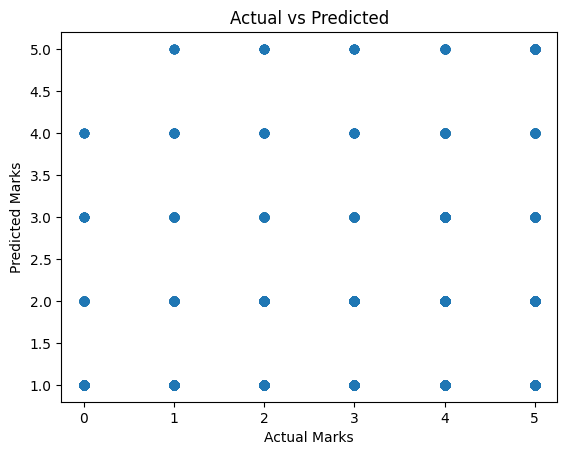

In [22]:
#Plotting
plt.scatter(train["teacher_marks"], train["predicted_marks"])
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

In [23]:
#running on testing data

test_sim = []

for i in range(len(test)):
    sim = cosine_similarity(test_ref_vec[i], test_stu_vec[i])[0][0]
    test_sim.append(sim)

test["similarity"] = test_sim
test["predicted_marks"] = test["similarity"].apply(sim_to_marks)

test[["predicted_marks"]].head()

,predicted_marks
0,2
1,1
2,1
3,2
4,3
